<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_1/enc_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 1: Primeiros Passos

**Instrutor:** Jhonatan Lopes


## 1. Our Lab: Google Colab e Jupyter Notebooks

Um notebook é um documento interativo que mistura:
1. **Células de Texto** (como esta, escritas em Markdown)
2. **Células de Código** (onde escrevemos Python)

O código que você escreve aqui não roda no seu computador, mas sim em um servidor (um computador potente) do Google. Esse servidor é o nosso *Environment* (Ambiente) ou *Runtime* (Ambiente de Execução).

# notebook - editor de texto e código super interativo

# textotextotextotexto
## textotextotextotexto
### textotextotextotexto

**Texto em negrito**

*Texto em itálico*

texto em **negrito** e *itálico* ao mesmo tempo

- Lista
- de
- itens 
1) numeração 
2) numeração
3) numeração

> citação
> 
> citação
> 
> citação  

## Fórmulas e Equações: 

Media:
$$\text{media} = \frac{x_1 + x_2 + ... + x_n}{n}$$
Mediana: 
$$\text{mediana} = \begin{cases}
x_{\frac{n+1}{2}}, & \text{se } n \text{ é ímpar} \\
\frac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2}, & \text{se } n \text{ é par}
\end{cases}$$
Desvio padrão:
$$\text{desvio padrão} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \text{media})^2}$$
Z-score:
$$z_i = \frac{x_i - \text{media}}{\text{desvio padrão}}$$
Distribuição Normal:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$$


## Imagens:
![UFMG](https://upload.wikimedia.org/wikipedia/commons/b/b5/Logo_UFMG.jpg)

![PYTHON](https://jupytearth.org/_images/python-stack.png)

In [1]:
import spacy
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import urllib.request

sns.set_theme(style="whitegrid", context="talk")

In [ ]:
# !python -m spacy download pt_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
nlp = nlp = spacy.load("pt_core_news_lg", disable=["ner"])

In [25]:
URL_LIVRO = "https://raw.githubusercontent.com/jhlopesalves/eda_humanidades/refs/heads/main/encontro_1/data/memorias_postumas.txt"
caminho = Path("memorias_postumas.txt")

if not caminho.exists():
    urllib.request.urlretrieve(URL_LIVRO, caminho)

texto = caminho.read_text(encoding="utf-8")
print(f"{len(texto):,} caracteres")
print(f"{len(texto.split()):,} palavras (contagem ingênua por espaços)")

387,705 caracteres
64,622 palavras (contagem ingênua por espaços)


In [26]:
memorias_postumas_doc = nlp(texto)
print(f"{len(memorias_postumas_doc):,} tokens processados por spaCy")

84,278 tokens processados por spaCy


In [27]:
# Contagem ingênua: o que qualquer um faz sem NLP / Python
tokens_crus = [t.text.lower() for t in memorias_postumas_doc if t.is_alpha]
top_crus = Counter(tokens_crus).most_common(15)

df_crus = pd.DataFrame(top_crus, columns=["palavra", "frequencia"])
df_crus

,palavra,frequencia
0,a,2598
1,que,2193
2,de,2137
3,e,2012
4,o,1835
5,não,1120
6,um,996
7,do,744
8,uma,664
9,da,657


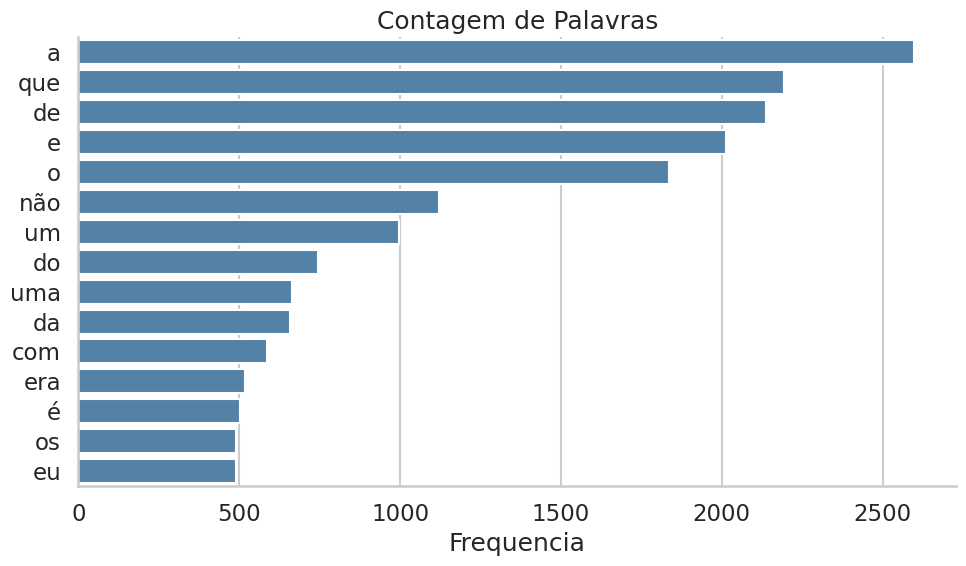

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_crus, x="frequencia", y="palavra", ax=ax, color="steelblue",
)
ax.set_title("Contagem de Palavras")
ax.set(xlabel="Frequencia", ylabel="")
sns.despine()

plt.tight_layout()
plt.show()

In [37]:
verbos_lema = [t.lemma_.lower() for t in memorias_postumas_doc if t.pos_ == "VERB"]
top_verbos = Counter(verbos_lema).most_common(20)

df_verbos = pd.DataFrame(top_verbos, columns=["verbo", "frequencia"])
df_verbos

,verbo,frequencia
0,dizer,330
1,ter,264
2,fazer,148
3,poder,135
4,saber,128
5,dar,126
6,ver,109
7,ser,94
8,ir,82
9,ficar,79


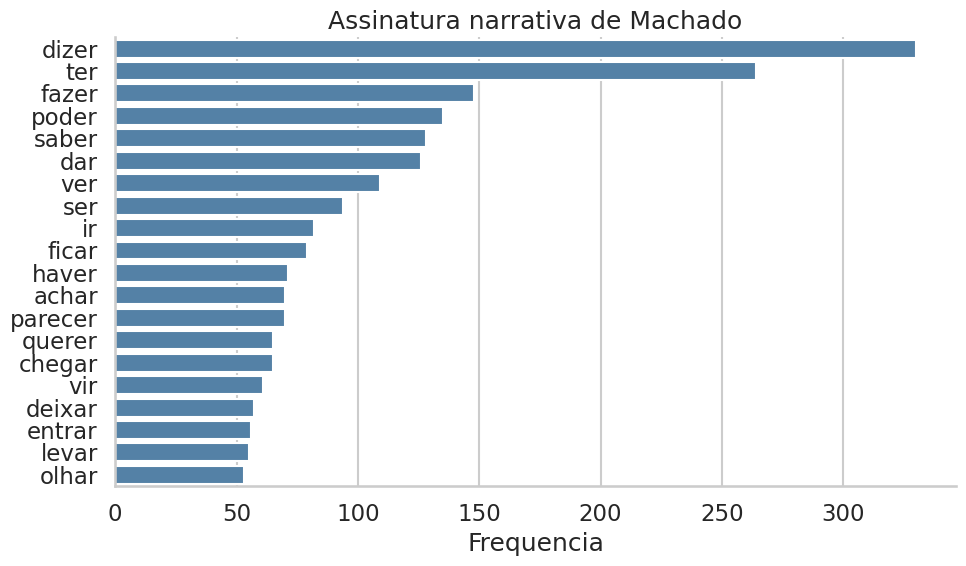

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_verbos, x="frequencia", y="verbo", ax=ax, color="steelblue")
ax.set_title("Assinatura narrativa de Machado")
ax.set(xlabel="Frequencia", ylabel="")

sns.despine()
plt.tight_layout()
plt.show()

In [39]:
df_verbos.describe()

,frequencia
count,20.000000
mean,105.900000
std,72.403039
min,53.000000
25%,64.000000
50%,75.000000
75%,126.500000
max,330.000000


In [46]:
# (We exclude punctuation and spaces to make the data cleaner, but you can remove the if statement if you want them)
pos_tags = [t.pos_ for t in memorias_postumas_doc if t.pos_ not in ["PUNCT", "SPACE"]]

# 2. Count the frequencies of each tag
pos_counts = Counter(pos_tags).most_common()

# 3. Create the DataFrame
df_pos = pd.DataFrame(pos_counts, columns=["pos_tag", "frequencia"])

# Display the top rows
df_pos.head(10)

,pos_tag,frequencia
0,NOUN,13549
1,VERB,9093
2,ADP,7838
3,DET,7827
4,PROPN,6085
5,ADV,4253
6,ADJ,3813
7,PRON,3746
8,CCONJ,2803
9,SCONJ,2527


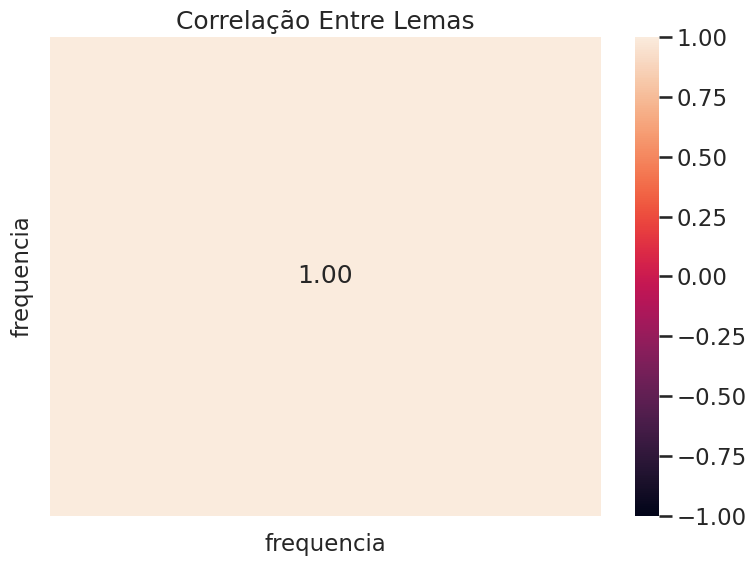

In [47]:
corr_matrix = df_pos.select_dtypes(include="number").corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    data=corr_matrix,
    vmin=-1,
    vmax=1,
    cbar="coolwarm",
    fmt=".2f",
    annot=True,
    ax=ax
)
ax.set_title("Correlação Entre Lemas")
plt.tight_layout()
plt.show()